## Import Libraries

In [1]:
# !pip install -q tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from keras import ops
import numpy as np
import matplotlib.pyplot as plt


## Load Cifar 10 dataset

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Use only 5000 training samples
x_train = x_train[:5000]
y_train = y_train[:5000]

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training set:", x_train.shape, y_train.shape)
print("Test set:", x_test.shape, y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training set: (5000, 32, 32, 3) (5000,)
Test set: (10000, 32, 32, 3) (10000,)


## Create Small CNN

In [3]:
def create_small_cnn():
    model = keras.Sequential([
        keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10),
    ])
    return model

small_cnn = create_small_cnn()
small_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## Pretrained CNN(MobileNetv2 and DenseNet121)


In [4]:
def build_finetuned_model(base_model_class):
    base_model = base_model_class(
        include_top=False,
        weights="imagenet",
        input_shape=(32, 32, 3),
        pooling="avg"
    )
    base_model.trainable = True

    # Freeze all but last 2 layers
    for layer in base_model.layers[:-2]:
        layer.trainable = False

    inputs = keras.Input(shape=(32, 32, 3))
    x = base_model(inputs, training=False)
    outputs = layers.Dense(10)(x)
    model = keras.Model(inputs, outputs)
    return model

densenet = build_finetuned_model(tf.keras.applications.DenseNet121)
mobilenet = build_finetuned_model(tf.keras.applications.MobileNetV2)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/tmp/ipython-input-4-1532235953.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = base_model_class(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Finetuning Pretrained CNN

In [5]:
for model, name in zip([densenet, mobilenet], ["DenseNet", "MobileNet"]):
    print(f"\nTraining {name}...")
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )
    model.fit(x_train, y_train, epochs=15, batch_size=64, verbose=1)
    test_loss, test_acc = model.evaluate(x_test, y_test)
    print(f"{name} Test Accuracy: {test_acc:.4f}")



Training DenseNet...
Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 112ms/step - accuracy: 0.1941 - loss: 2.5323
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4612 - loss: 1.5305
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5386 - loss: 1.3482
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5742 - loss: 1.2115
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6164 - loss: 1.1219
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6276 - loss: 1.0915
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6442 - loss: 1.0339
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6651 - loss: 0.9921
Epoch 9/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6753 - loss: 0.9583
Epoch 10/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6766 - loss: 0.9410
Epoch 11/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6951 - loss: 0.9033
Epoch 12/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 

## Distiller Class for single teacher

In [6]:
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, loss, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=3):
        super().compile(optimizer=optimizer, loss=loss, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        teacher_pred = self.teacher(x, training=False)
        with tf.GradientTape() as tape:
            student_pred = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_pred)
            distill_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_pred / self.temperature),
                tf.nn.softmax(student_pred / self.temperature),
            ) * (self.temperature**2)
            loss = self.alpha * student_loss + (1 - self.alpha) * distill_loss
        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self.compiled_metrics.update_state(y, student_pred)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        y_pred = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_pred)
        self.compiled_metrics.update_state(y, y_pred)
        return {m.name: m.result() for m in self.metrics}

    def call(self, x):
        return self.student(x)


## Train Small CNN

In [7]:
small_scratch = create_small_cnn()
small_scratch.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)
history_scratch = small_scratch.fit(x_train, y_train, epochs=15, batch_size=64, verbose=1)
test_loss_scratch, test_acc_scratch = small_scratch.evaluate(x_test, y_test)


Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.1756 - loss: 2.1950
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3856 - loss: 1.7087
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4470 - loss: 1.5548
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4933 - loss: 1.4064
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5122 - loss: 1.3463
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5831 - loss: 1.1834
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5994 - loss: 1.1483
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6228 - loss: 1.0809
Epoch 9/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6345 - loss: 1.0720
Epoch 10/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6627 - loss: 0.9578
Epoch 11/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7018 - loss: 0.8659
Epoch 12/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7264 - l

## Single Distillation DenseNet

In [8]:
student_single = create_small_cnn()
distiller_single = Distiller(student=student_single, teacher=densenet)
distiller_single.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # 👈 Required for evaluate()
    metrics=["accuracy"],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=10,
)

history_single = distiller_single.fit(x_train, y_train, epochs=15, batch_size=64, verbose=1)
test_loss_single, test_acc_single = distiller_single.evaluate(x_test, y_test)


Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:642: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - accuracy: 0.1705 - loss: 0.0744
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3533 - loss: 0.2353
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4178 - loss: 0.2879
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4576 - loss: 0.2345
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4873 - loss: 0.1833
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5149 - loss: 0.1941
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5389 - loss: 0.1744
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5226 - loss: 0.1206
Epoch 9/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5555 - loss: 0.0843
Epoch 10/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5526 - loss: 0.1255
Epoch 11/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5772 - loss: 0.0875
Epoch 12/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5919 -

## Multiple Distiller Class



In [9]:
class MultiTeacherDistiller(keras.Model):
    def __init__(self, student, teachers):
        super().__init__()
        self.teachers = teachers
        self.student = student

    def compile(self, optimizer, loss, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=3):
        super().compile(optimizer=optimizer, loss=loss, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        teacher_preds = [t(x, training=False) for t in self.teachers]
        soft_teacher = tf.reduce_mean(
            tf.stack([tf.nn.softmax(tp / self.temperature) for tp in teacher_preds]),
            axis=0,
        )

        with tf.GradientTape() as tape:
            student_pred = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_pred)
            distill_loss = self.distillation_loss_fn(
                soft_teacher,
                tf.nn.softmax(student_pred / self.temperature),
            ) * (self.temperature**2)
            loss = self.alpha * student_loss + (1 - self.alpha) * distill_loss

        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self.compiled_metrics.update_state(y, student_pred)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        y_pred = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_pred)
        self.compiled_metrics.update_state(y, y_pred)
        return {m.name: m.result() for m in self.metrics}

    def call(self, x):
        return self.student(x)


## ## Multiple Distillation (DenseNet + MobileNetv2)

In [10]:
student_dual = create_small_cnn()
multi_distiller = MultiTeacherDistiller(student=student_dual, teachers=[densenet, mobilenet])
multi_distiller.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=10,
)

history_dual = multi_distiller.fit(x_train, y_train, epochs=15, batch_size=64, verbose=1)
test_loss_dual, test_acc_dual = multi_distiller.evaluate(x_test, y_test)


Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 127ms/step - accuracy: 0.1935 - loss: 0.0467
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3761 - loss: 0.0243
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4372 - loss: 0.0881
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4633 - loss: 0.0508
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5106 - loss: 0.1011
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5435 - loss: 0.0742
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5388 - loss: 0.0750
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5652 - loss: 0.0571
Epoch 9/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5937 - loss: 0.0617
Epoch 10/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5807 - loss: 0.0560
Epoch 11/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6263 - loss: 0.0385
Epoch 12/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accurac

## Plot graph

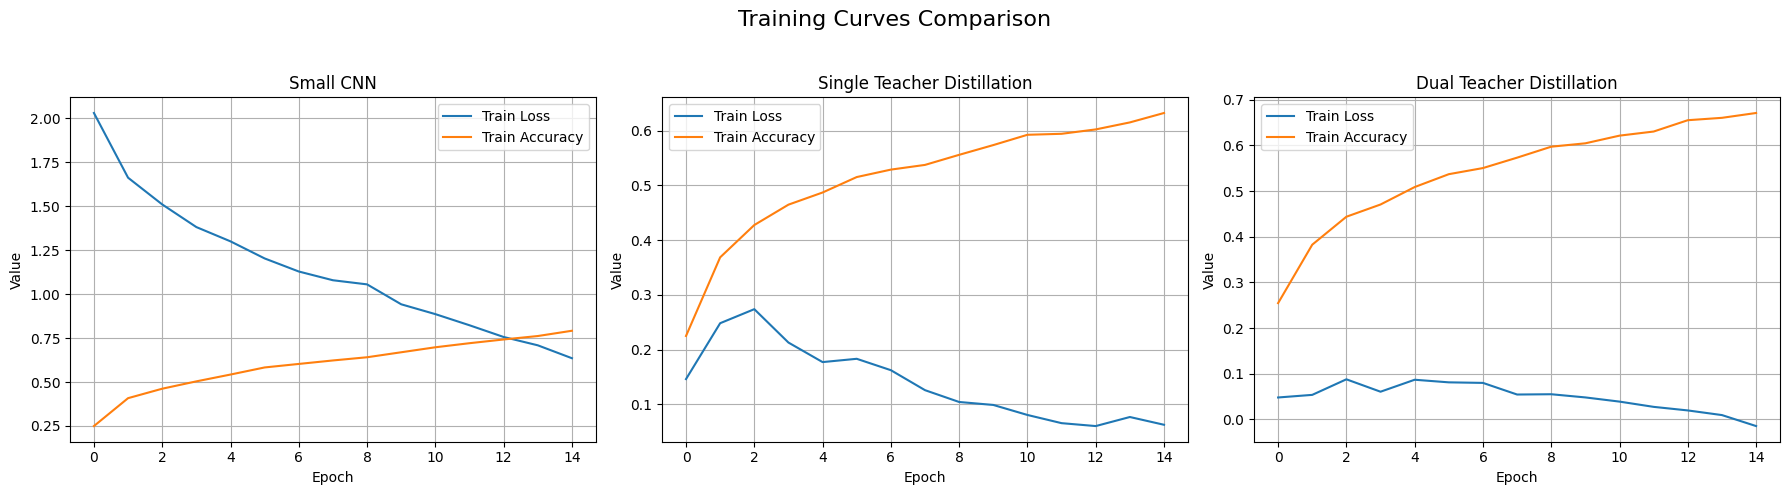

In [19]:
import matplotlib.pyplot as plt

# Define the function for plotting
def plot_all_trainings(histories, titles):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, history, title in zip(axes, histories, titles):
        # Plot training loss
        ax.plot(history.history['loss'], label='Train Loss')

        # Plot validation loss if available
        if 'val_loss' in history.history:
            ax.plot(history.history['val_loss'], label='Val Loss')

        # Plot training accuracy if available
        if 'accuracy' in history.history:
            ax.plot(history.history['accuracy'], label='Train Accuracy')

        # Plot validation accuracy if available
        if 'val_accuracy' in history.history:
            ax.plot(history.history['val_accuracy'], label='Val Accuracy')

        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Value')
        ax.grid(True)
        ax.legend()

    plt.suptitle("Training Curves Comparison", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Call the plotting function
plot_all_trainings(
    [history_scratch, history_single, history_dual],
    ['Small CNN', 'Single Teacher Distillation', 'Dual Teacher Distillation']
)


In [18]:
# Extract the tensor from the dict first
test_acc_single_val = test_acc_single['accuracy'].numpy()
test_acc_dual_val = test_acc_dual['accuracy'].numpy()

# Now print with formatting
print(f"Test Accuracy (Small CNN): {test_acc_scratch:.4f}")
print(f"Test Accuracy (Single Teacher): {test_acc_single_val:.4f}")
print(f"Test Accuracy (Dual Teacher): {test_acc_dual_val:.4f}")


Test Accuracy (Small CNN): 0.5602
Test Accuracy (Single Teacher): 0.5657
Test Accuracy (Dual Teacher): 0.5625
